

# Imports



In [1]:
import pvlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import optuna, lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, Baseline, TimeSeriesDataSet
from pytorch_forecasting.metrics import MAE, RMSE, QuantileLoss
from optuna.pruners import HyperbandPruner
from optuna.integration import PyTorchLightningPruningCallback

/srv/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
# Number of GPUs available
print("GPUs available:", torch.cuda.device_count())

GPUs available: 1


# The Dataset

## PV Class and Important Data Functions

In [3]:
# Class
import pvlib

class PVPark:
    def __init__(self, name, latitude, longitude, altitude, tz, tilt, azimuth, nominal_capacity):
        self.location = pvlib.location.Location(latitude=latitude, longitude=longitude, altitude=altitude, tz=tz, name=name)
        self.tilt = tilt
        self.azimuth = azimuth
        self.nominal_capacity = nominal_capacity

    @classmethod
    def from_dataframe(cls, df, index=0):
        row = df.iloc[index]

        lat = row['latitude']
        azimuth = row['azimuth'] if pd.notnull(row['azimuth']) else 180.0
        tilt = row['tilt'] if pd.notnull(row['tilt']) else lat
        altitude = row['altitude'] if pd.notnull(row['altitude']) else None

        return cls(
            name=row['name'],
            latitude=lat,
            longitude=row['longitude'],
            altitude=altitude,
            tz=row['tz'],
            tilt=tilt,
            azimuth=azimuth,
            nominal_capacity=row['nominal_capacity']
        )

In [4]:
def scale_active_power(df, pv_park):
    # Scale and clip the target at 1.0
    df['active_power'] = (df['active_power'] / pv_park.nominal_capacity)
    df['active_power'] = df['active_power'].clip(upper=1.0)
    return df

In [5]:
def print_correlations(df):
    df_corr = df.corr()
    abs_corr = df_corr['active_power'].abs().sort_values(ascending=False)
    print(abs_corr)

In [6]:
def add_group_and_time_idx(df):
    # Extract day string for group_id
    df["group_id"] = 0
    # Assign time_idx per group (e.g., 0 to 287)
    df["time_idx"] = range(len(df))
    return df

## Load metadata and create park info

In [7]:
base_dir="/home/ubuntu/work"
feature_type= "feature-engineered"
weather_source= "station"

In [8]:
df = pd.read_csv(f"{base_dir}/data/Gasi-CN448/metadata.csv")
# Create PVPark instance from DataFrame
pv_park = PVPark.from_dataframe(df)
print(pv_park.location)
print(pv_park.tilt)
print(pv_park.azimuth)
print(pv_park.nominal_capacity)

Location: 
  name: Gasi-CN448
  latitude: 35.13
  longitude: 25.259
  altitude: 334.0
  tz: Europe/Athens
25.0
180.0
405.0


## Load unprocessed data

In [9]:
df = pd.read_csv(f"{base_dir}/data/Gasi-CN448/{feature_type}/{weather_source}/data.csv")

print(df.head())

          collect_time  active_power  irradiance  poa_global  cos_aoi  dni  \
0  2023-08-12 00:00:00           0.0         0.0         0.0      0.0  0.0   
1  2023-08-12 00:05:00           0.0         0.0         0.0      0.0  0.0   
2  2023-08-12 00:10:00           0.0         0.0         0.0      0.0  0.0   
3  2023-08-12 00:15:00           0.0         0.0         0.0      0.0  0.0   
4  2023-08-12 00:20:00           0.0         0.0         0.0      0.0  0.0   

   dhi  temperature  cos_time  
0  0.0         20.6  1.000000  
1  0.0         20.6  0.999762  
2  0.0         20.6  0.999048  
3  0.0         20.6  0.997859  
4  0.0         20.6  0.996195  


## Data Cleaning and Preparing for TFT

### Autoscale active power

In [10]:
df = scale_active_power(df, pv_park)

print(df.head())

          collect_time  active_power  irradiance  poa_global  cos_aoi  dni  \
0  2023-08-12 00:00:00           0.0         0.0         0.0      0.0  0.0   
1  2023-08-12 00:05:00           0.0         0.0         0.0      0.0  0.0   
2  2023-08-12 00:10:00           0.0         0.0         0.0      0.0  0.0   
3  2023-08-12 00:15:00           0.0         0.0         0.0      0.0  0.0   
4  2023-08-12 00:20:00           0.0         0.0         0.0      0.0  0.0   

   dhi  temperature  cos_time  
0  0.0         20.6  1.000000  
1  0.0         20.6  0.999762  
2  0.0         20.6  0.999048  
3  0.0         20.6  0.997859  
4  0.0         20.6  0.996195  


### Add group & time index

In [11]:
df = add_group_and_time_idx(df)

print(df.head())

          collect_time  active_power  irradiance  poa_global  cos_aoi  dni  \
0  2023-08-12 00:00:00           0.0         0.0         0.0      0.0  0.0   
1  2023-08-12 00:05:00           0.0         0.0         0.0      0.0  0.0   
2  2023-08-12 00:10:00           0.0         0.0         0.0      0.0  0.0   
3  2023-08-12 00:15:00           0.0         0.0         0.0      0.0  0.0   
4  2023-08-12 00:20:00           0.0         0.0         0.0      0.0  0.0   

   dhi  temperature  cos_time  group_id  time_idx  
0  0.0         20.6  1.000000         0         0  
1  0.0         20.6  0.999762         0         1  
2  0.0         20.6  0.999048         0         2  
3  0.0         20.6  0.997859         0         3  
4  0.0         20.6  0.996195         0         4  


### Define Train and Validation Dataframes

In [12]:
# define split dates (inclusive / exclusive boundaries)
train_start = "2023-08-12"
train_end   = "2024-10-15"
val_start   = "2024-10-16"
val_end     = "2025-01-31"

# filter by date
train_df = df[(df["collect_time"] >= train_start) & (df["collect_time"] <= train_end)]
val_df = df[(df["collect_time"] >= val_start) & (df["collect_time"] <= val_end)]


# The Model

## Define Dataset Function

In [13]:
def make_dataset(df, enc_len):
    return TimeSeriesDataSet(
        df,
        time_idx="time_idx",
        target="active_power",
        group_ids=["group_id"],
        min_encoder_length=enc_len, max_encoder_length=enc_len,
        min_prediction_length=1, max_prediction_length=1,
        time_varying_known_reals=[
            "irradiance", "poa_global", "cos_aoi", "dni", "dhi", "temperature", "cos_time"
        ],
        time_varying_unknown_reals=[],
        add_relative_time_idx=True,
        add_encoder_length=True,
        add_target_scales=False,
    )

## Hyperparameter Tuning

In [ ]:
def objective(trial):
    enc_len = trial.suggest_int("encoder_length", 48, 288, step=48)  # tune context size
    
    # reuse the same TimeSeriesDataSet definition (tft_dataset)
    train_dataset = make_dataset(train_df, enc_len)
    val_dataset = TimeSeriesDataSet.from_dataset(train_dataset, val_df)

    # create Dataloaders
    train_dataloader = train_dataset.to_dataloader(train=True, batch_size=64, num_workers=2)
    val_dataloader = val_dataset.to_dataloader(train=False, batch_size=64, num_workers=2)

    model = TemporalFusionTransformer.from_dataset(
        train_dataset,
        loss=QuantileLoss(),
        learning_rate=trial.suggest_float("lr", 1e-4, 1e-3, log=True),
        hidden_size=trial.suggest_int("hidden_size", 32, 128, step=32),
        hidden_continuous_size=trial.suggest_int("hidden_continuous_size", 16, 64, step=16),
        attention_head_size=trial.suggest_int("attention_head_size", 1, 4),
        dropout=trial.suggest_float("dropout", 0.05, 0.3),
        optimizer="adam",
        reduce_on_plateau_patience=4,
    )

    trainer = pl.Trainer(
        max_epochs=2,
        accelerator="gpu",
        callbacks=[PyTorchLightningPruningCallback(trial, monitor="val_loss")],
        enable_progress_bar=True,
    )
    
    trainer.fit(model, train_dataloader, val_dataloader)
    return float(trainer.callback_metrics["val_loss"])

study = optuna.create_study(direction="minimize", pruner=HyperbandPruner())
study.optimize(objective, n_trials=2)
print("Best:", study.best_trial.params)

## Training

In [14]:
enc_len = 144  # tune context size

# reuse the same TimeSeriesDataSet definition (tft_dataset)
train_dataset = make_dataset(train_df, enc_len)
val_dataset = TimeSeriesDataSet.from_dataset(train_dataset, val_df)

# create Dataloaders
train_dataloader = train_dataset.to_dataloader(train=True, batch_size=64, num_workers=2)
val_dataloader = val_dataset.to_dataloader(train=False, batch_size=64, num_workers=2)

tft = TemporalFusionTransformer.from_dataset(
    train_dataset,
    loss=QuantileLoss(),
    learning_rate= 5e-3,
    hidden_size= 64,
    hidden_continuous_size= 32,
    attention_head_size= 3,
    dropout= 0.1,
    optimizer="adam",
    reduce_on_plateau_patience=4,
)

early_stop_callback = pl.callbacks.EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    logger=False,
    callbacks=[early_stop_callback],
    enable_progress_bar=True,
)

trainer.fit(tft, train_dataloader, val_dataloader)

trainer.save_checkpoint("tft_final.ckpt")

/srv/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/srv/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/srv/venv/lib/python3.12/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as

Epoch 0: 100%|██████████| 1932/1932 [05:41<00:00,  5.65it/s, train_loss_step=0.010]  
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 1932/1932 [05:38<00:00,  5.71it/s, train_loss_step=0.00704, val_loss=0.0113, train_loss_epoch=0.0157]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 1932/1932 [05:39<00:00,  5.70it/s, train_loss_step=0.0076, val_loss=0.00839, train_loss_epoch=0.00938] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 1932/1932 [05:52<00:00,  5.48it/s, train_loss_step=0.00821, val_loss=0.00797, train_loss_epoch=0.00831]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 1932/1932 [06:01<00:00,  5.34it/s, train_loss_step=0.010, val_loss=0.00682, train_loss_epoch=0.00769]  
Validation: |          | 0/?

## Evaluation

In [15]:
raw_predictions = tft.predict(
    val_dataloader, mode="raw", return_x=True, trainer_kwargs=dict(accelerator="gpu")
)

interpretation=tft.interpret_output(raw_predictions.output)

import torch
avg_importance = interpretation["decoder_variables"].mean(dim=0)

feature_names = ["irradiance", "poa_global", "cos_aoi", "dni", "dhi", "temperature", "cos_time"]
# feature_names = ["irradiance", "temperature", "wind_speed"]

importance_dict = dict(zip(feature_names, avg_importance.tolist()))
sorted_importance = dict(sorted(importance_dict.items(), key=lambda item: item[1], reverse=True))

for feature, score in sorted_importance.items():
    print(f"{feature:20s} → {score:.4f}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


irradiance           → 0.5233
dhi                  → 0.0998
cos_aoi              → 0.0949
cos_time             → 0.0881
dni                  → 0.0808
poa_global           → 0.0547
temperature          → 0.0540


## Generate Predictions

In [16]:
predictions = tft.predict(val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="gpu"))

y_pred = predictions.output.detach().cpu().numpy()
y_true = predictions.y[0].detach().cpu().numpy()  # Access first element of the tuple

# Optional: Inverse scale if needed
y_pred_inv = y_pred * pv_park.nominal_capacity
y_true_inv = y_true * pv_park.nominal_capacity

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


## Metrics

In [17]:
import json
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

metrics = {
    "validation": {
        "r2": float(r2_score(y_true_inv.flatten(), y_pred_inv.flatten())),
        "rmse": float(np.sqrt(mean_squared_error(y_true_inv.flatten(), y_pred_inv.flatten()))),
        "mae": float(mean_absolute_error(y_true_inv.flatten(), y_pred_inv.flatten()))
    }
}
print(metrics)

# with open(f"{base_dir}/model/TFT/prediction-scenarios/{weather_source}/{features}/validation/metrics.json", "w") as f:
#     json.dump(metrics, f, indent=4)


{'validation': {'r2': 0.9869707657006189, 'rmse': 12.014001783974402, 'mae': 3.725827726766471}}


## Plots

In [18]:
y_pred_inv = y_pred_inv.squeeze()        # (30800,) -> drop the trailing dim
y_pred_inv = y_pred_inv[144:]                     # drop first 272 -> length 30528
y_pred_inv = y_pred_inv.reshape(-1, 288)          # -> shape (106, 288)
print(y_pred_inv.shape)

y_true_inv = y_true_inv.squeeze()        # (30800,) -> drop the trailing dim
y_true_inv = y_true_inv[144:]                     # drop first 272 -> length 30528
y_true_inv = y_true_inv.reshape(-1, 288)          # -> shape (106, 288)
print(y_true_inv.shape)

(106, 288)
(106, 288)


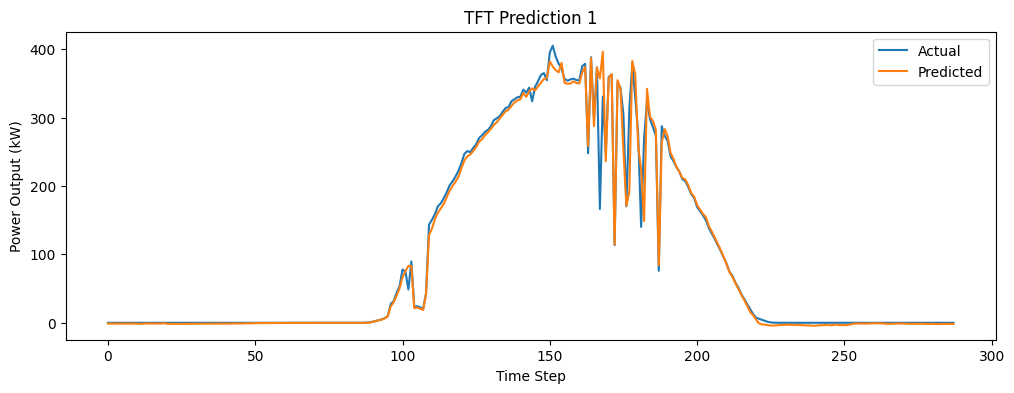

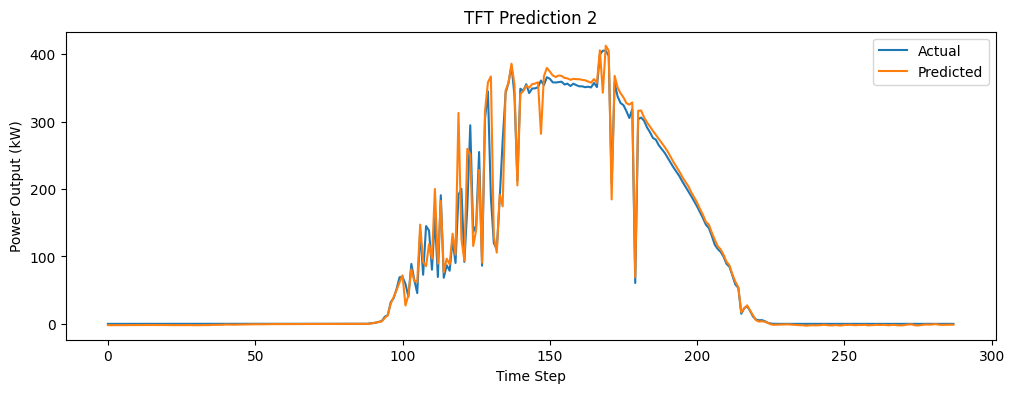

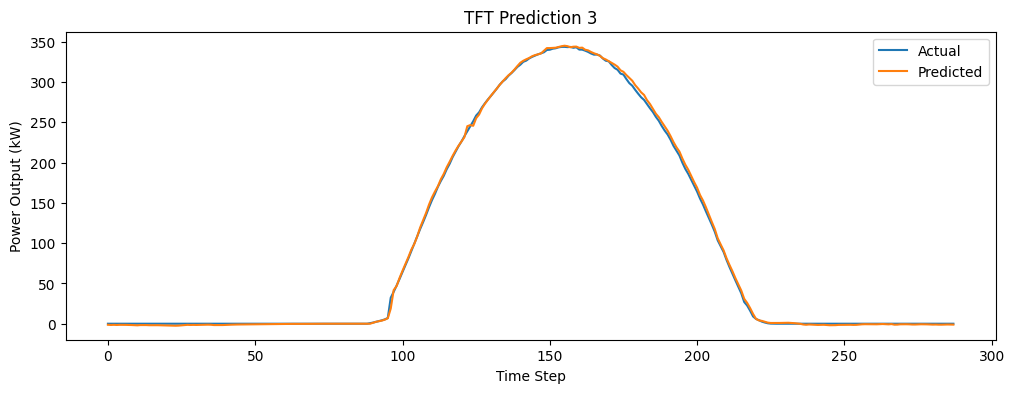

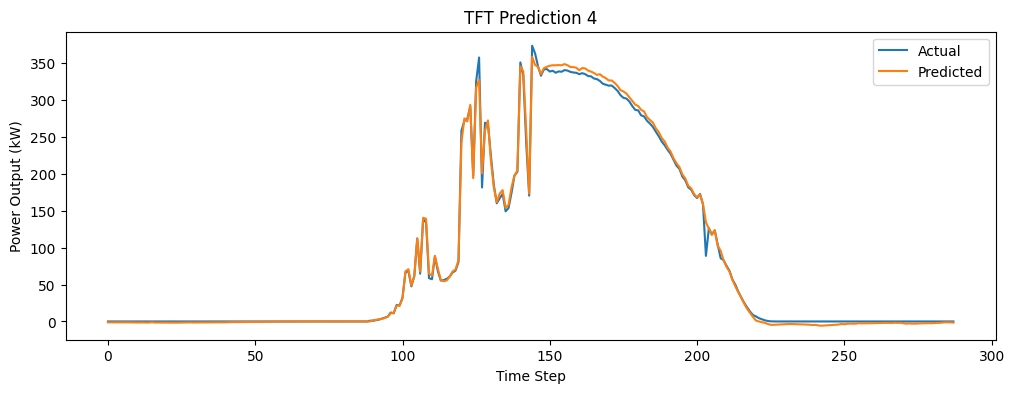

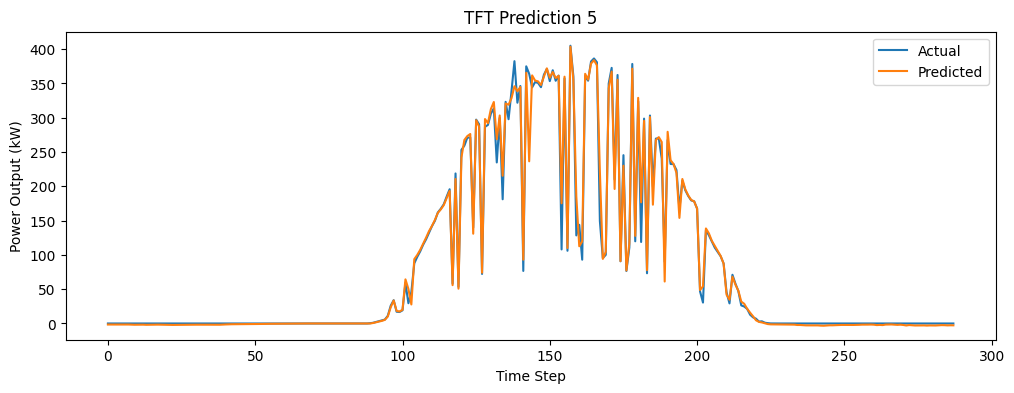

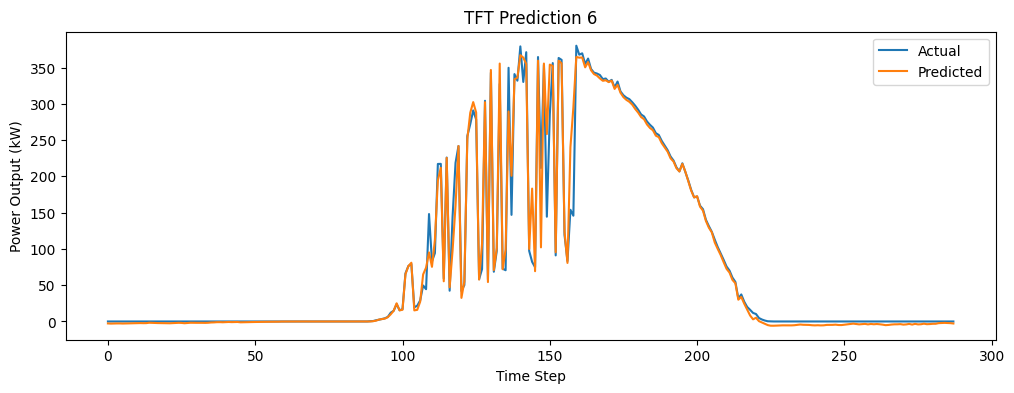

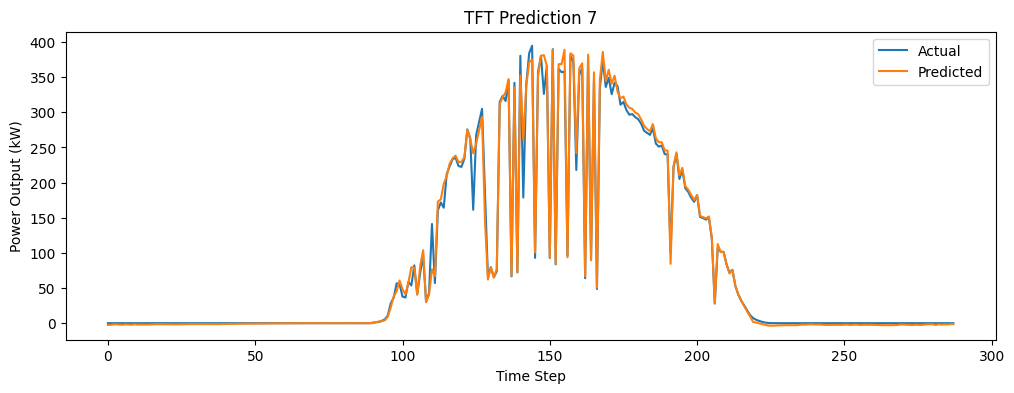

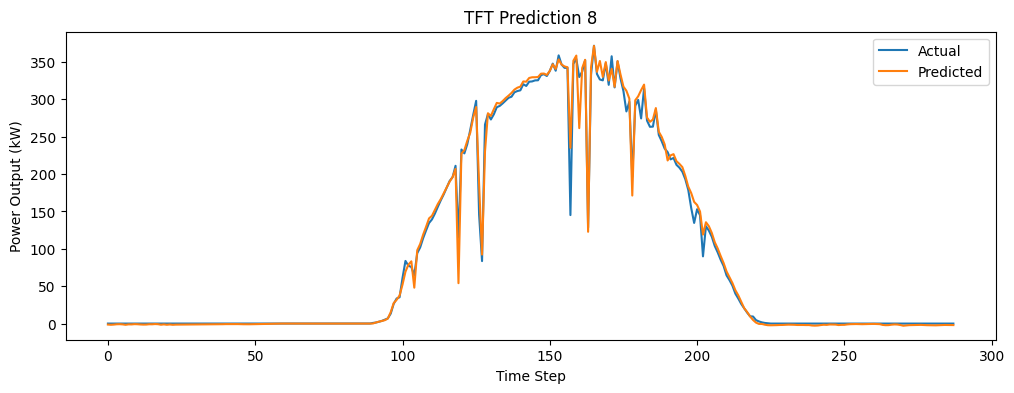

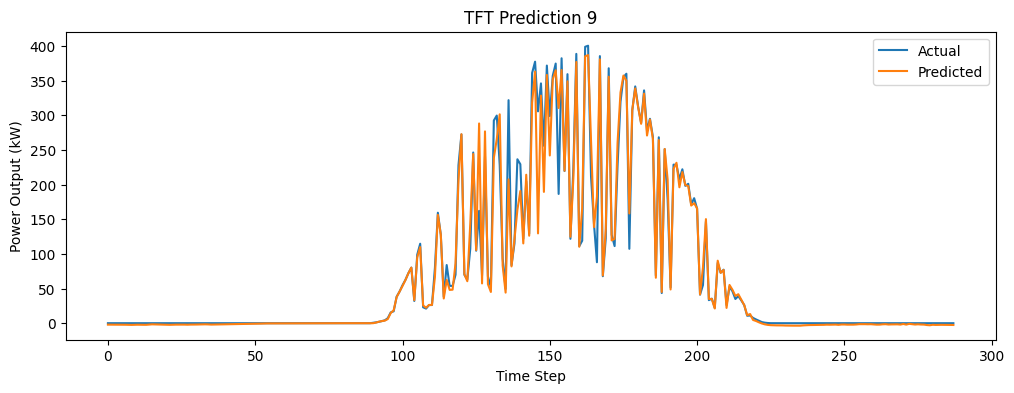

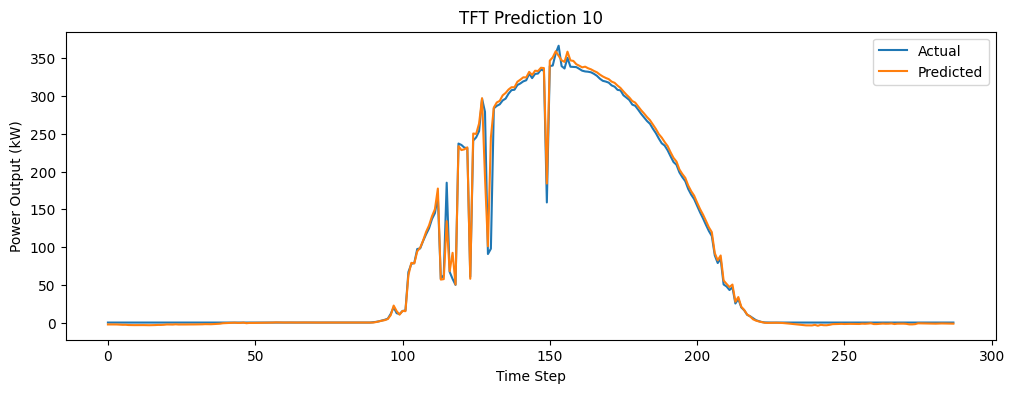

In [19]:
for i in range(10):
    plt.figure(figsize=(12, 4))
    plt.plot(y_true_inv[i], label='Actual')
    plt.plot(y_pred_inv[i], label='Predicted')
    plt.title(f"TFT Prediction {i+1}")
    plt.xlabel("Time Step")
    plt.ylabel("Power Output (kW)")  # Adjust based on units
    plt.legend()
    # plt.grid(True)
    # plt.savefig(f"{base_dir}/model/TFT/prediction-scenarios/{weather_source}/{features}/validation/prediction_{i+1}.png")
    plt.show()
    plt.close()

# Generate Data for another Park

## Load Metadata

In [20]:
df = pd.read_csv(f"{base_dir}/data/Sarafali-CN506/metadata.csv")
# Create PVPark instance from DataFrame
pv_park = PVPark.from_dataframe(df)

print(pv_park.location)
print(pv_park.tilt)
print(pv_park.azimuth)
print(pv_park.nominal_capacity)

Location: 
  name: Sarafali-CN506
  latitude: 35.13
  longitude: 25.259
  altitude: 334.0
  tz: Europe/Athens
20.0
180.0
1000.0


## Full-output

### Load Data & Extract Features

In [21]:
# Read data
df= pd.read_csv(f"{base_dir}/data/Sarafali-CN506/{feature_type}/{weather_source}/data.csv")

# Autoscale active power
df = scale_active_power(df, pv_park)

# Add group and time idx
df = add_group_and_time_idx(df)

print(df.head())
print(len(df)/288)

          collect_time  active_power  irradiance  poa_global  cos_aoi  dni  \
0  2023-09-01 00:00:00           0.0         0.0         0.0      0.0  0.0   
1  2023-09-01 00:05:00           0.0         0.0         0.0      0.0  0.0   
2  2023-09-01 00:10:00           0.0         0.0         0.0      0.0  0.0   
3  2023-09-01 00:15:00           0.0         0.0         0.0      0.0  0.0   
4  2023-09-01 00:20:00           0.0         0.0         0.0      0.0  0.0   

   dhi  temperature  cos_time  group_id  time_idx  
0  0.0         22.3  1.000000         0         0  
1  0.0         23.1  0.999762         0         1  
2  0.0         22.8  0.999048         0         2  
3  0.0         22.4  0.997859         0         3  
4  0.0         22.2  0.996195         0         4  
182.0


### Create Timeseries Dataset and dataloader

In [22]:
# Use same parameters as training set
new_dataset = TimeSeriesDataSet.from_dataset(train_dataset,  df)

new_dataloader = new_dataset.to_dataloader(train=False, batch_size=64, num_workers=2)

### Generate and Evaluate

In [23]:
predictions = tft.predict(new_dataloader, return_y=True, trainer_kwargs=dict(accelerator="gpu"))

y_pred = predictions.output.detach().cpu().numpy()
y_true = predictions.y[0].detach().cpu().numpy()  # Access first element of the tuple

# Optional: Inverse scale if needed
y_pred_inv = y_pred * pv_park.nominal_capacity
y_true_inv = y_true * pv_park.nominal_capacity

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


#### Metrics

In [24]:
import json
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

metrics = {
    "test": {
        "r2": float(r2_score(y_true_inv.flatten(), y_pred_inv.flatten())),
        "rmse": float(np.sqrt(mean_squared_error(y_true_inv.flatten(), y_pred_inv.flatten()))),
        "mae": float(mean_absolute_error(y_true_inv.flatten(), y_pred_inv.flatten()))
    }
}
print(metrics)

# with open(f"{base_dir}/model/TFT/prediction-scenarios/{weather_source}/{features}/test/2023-09/metrics.json", "w") as f:
#     json.dump(metrics, f, indent=4)

{'test': {'r2': 0.9785567445468681, 'rmse': 38.79754032212772, 'mae': 10.863018098964625}}


#### Plots

In [25]:
y_pred_inv = y_pred_inv.squeeze()        # (30800,) -> drop the trailing dim
y_pred_inv = y_pred_inv[144:]                     # drop first 272 -> length 30528
y_pred_inv = y_pred_inv.reshape(-1, 288)          # -> shape (106, 288)
print(y_pred_inv.shape)

y_true_inv = y_true_inv.squeeze()        # (30800,) -> drop the trailing dim
y_true_inv = y_true_inv[144:]                     # drop first 272 -> length 30528
y_true_inv = y_true_inv.reshape(-1, 288)          # -> shape (106, 288)
print(y_true_inv.shape)

(181, 288)
(181, 288)


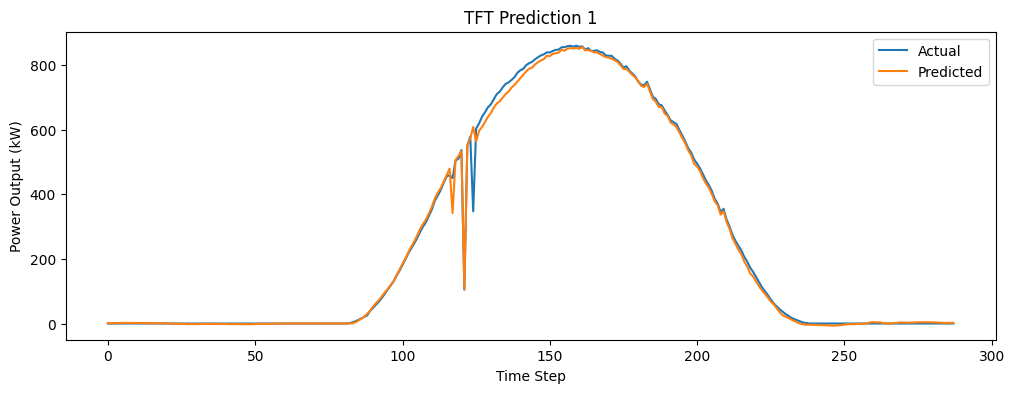

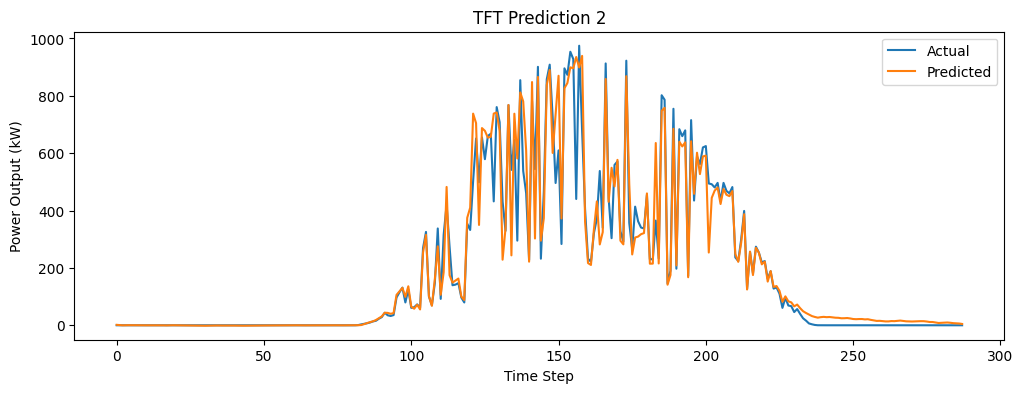

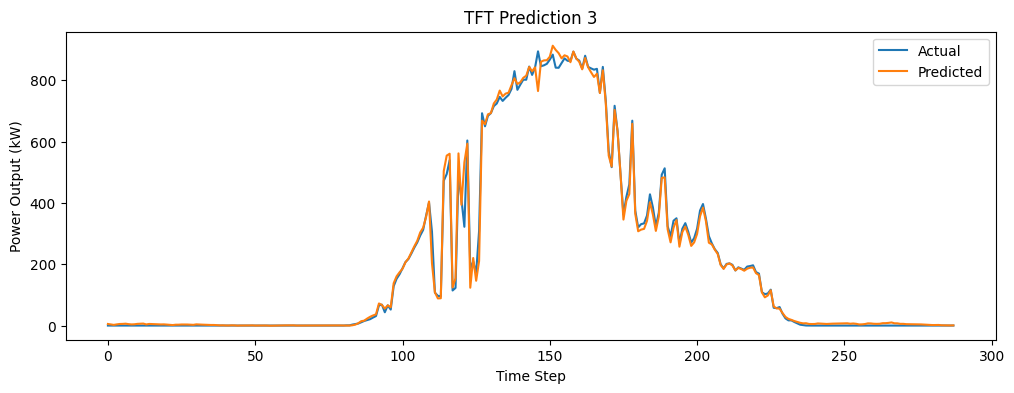

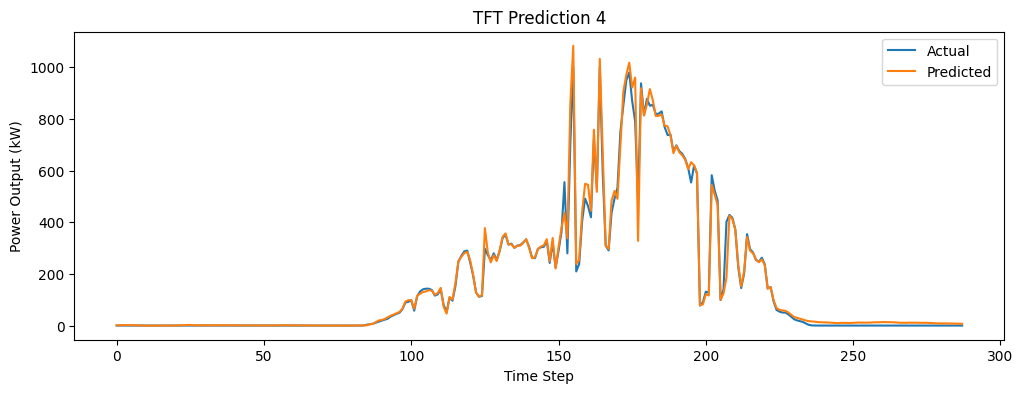

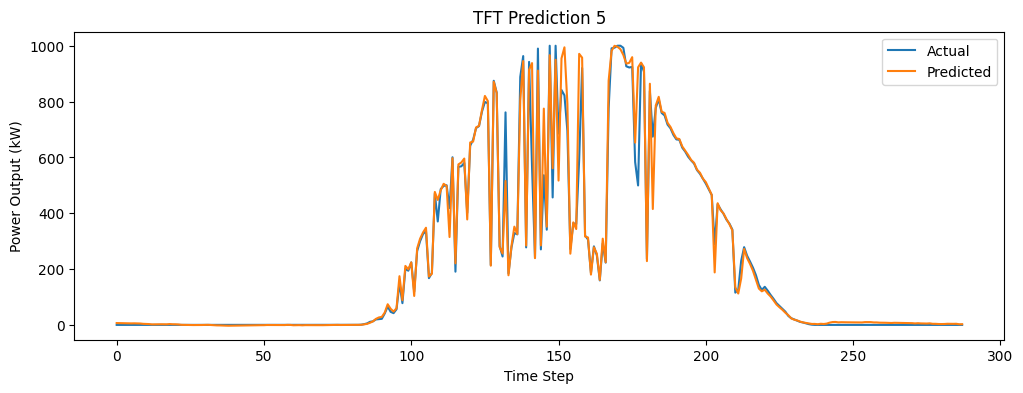

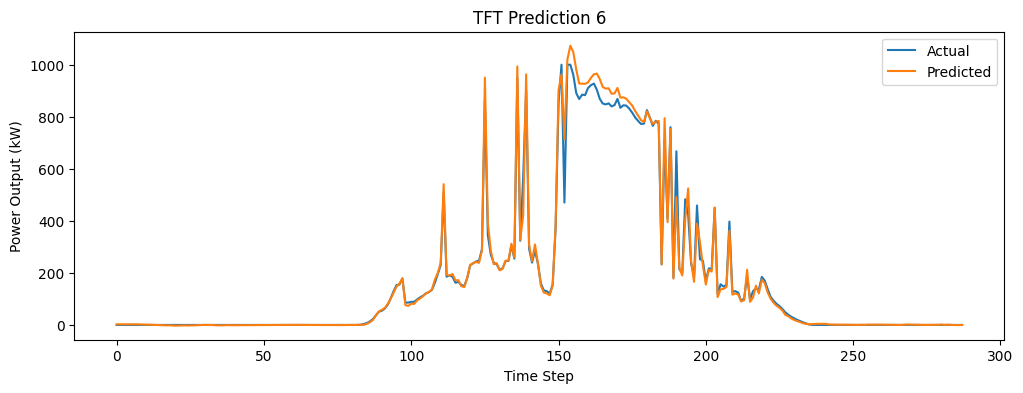

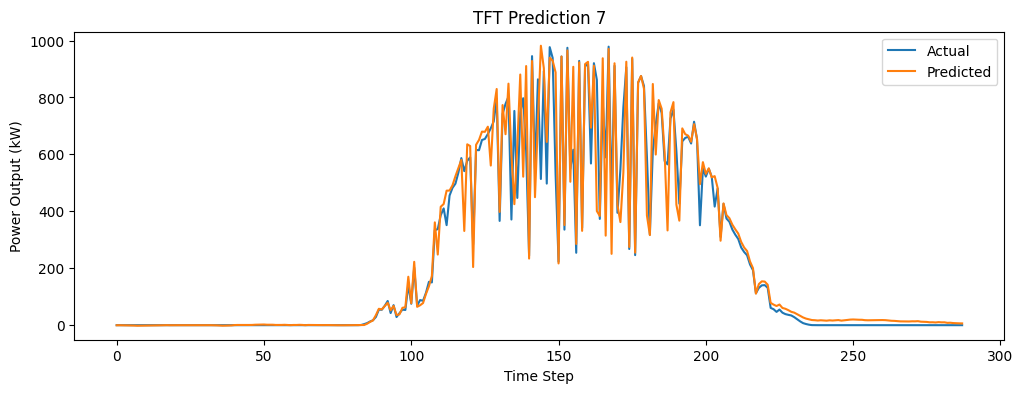

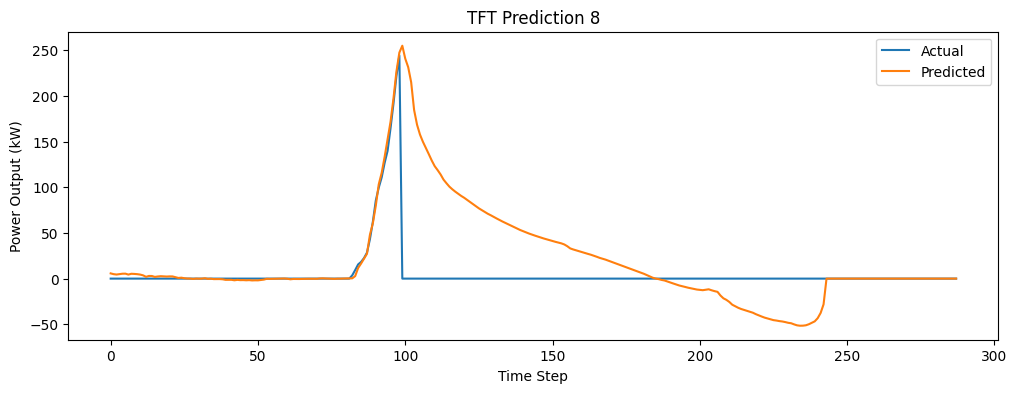

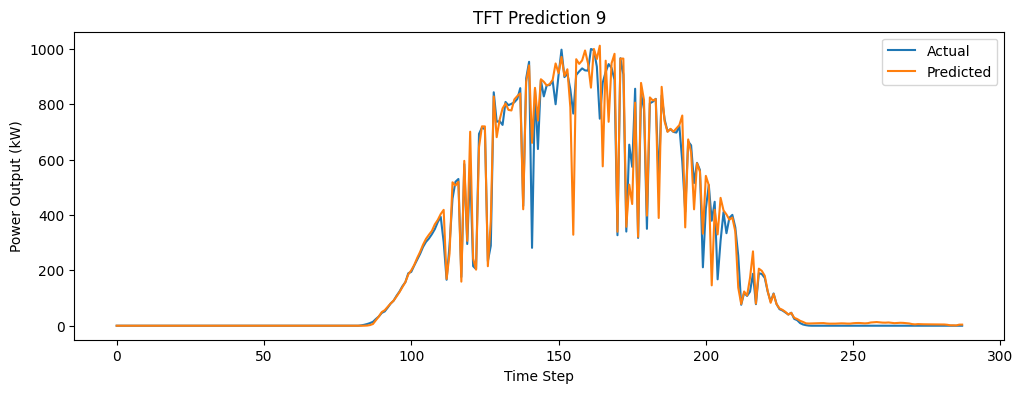

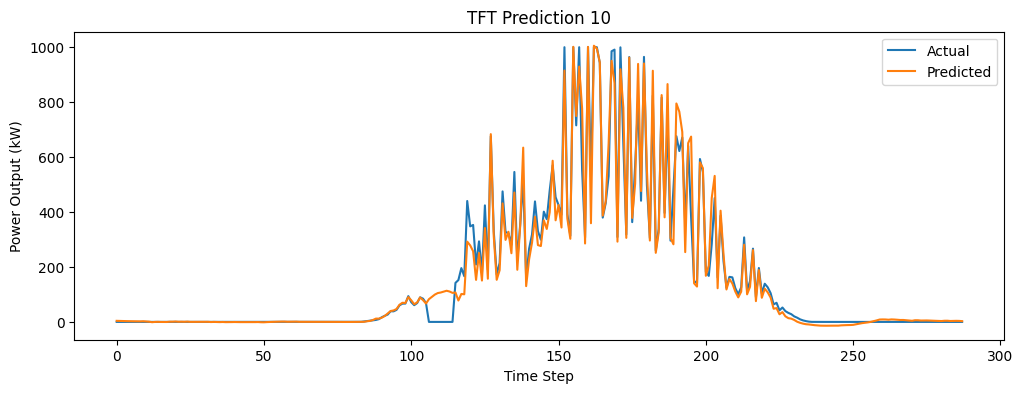

In [26]:
for i in range(10):
    plt.figure(figsize=(12, 4))
    plt.plot(y_true_inv[i], label='Actual')
    plt.plot(y_pred_inv[i], label='Predicted')
    plt.title(f"TFT Prediction {i+1}")
    plt.xlabel("Time Step")
    plt.ylabel("Power Output (kW)")  # Adjust based on units
    plt.legend()
    # plt.savefig(f"{base_dir}/model/TFT/prediction-scenarios/{weather_source}/{features}/test/2023-09/prediction_{i+1}.png")
    plt.show()
    plt.close()

In [30]:
# np.save(f"{base_dir}/data/Predictions/feature-engineered/open-meteo-curtailed/TFT_predictions.npy", y_pred_inv)

In [36]:
# print(len(y_pred_inv[1]))
# print(len(y_true_inv[1]))

47
47


## 2024-04 (trimmed-output)

### Load Data & Extract Features

In [39]:
# Read data
df= pd.read_csv(f"{base_dir}/data/Sarafali-CN506/final/{weather_source}/2024-04/data.csv")

# Get Solar Position
df = get_solar_position(df, pv_park)

# # Estimate dhi & dni
# df = estimate_dhi_dni(df, pv_park)

# Get POA
df = get_poa(df, pv_park)

# Calculate AOI
df = calc_aoi(df, pv_park)

# Add sin and cos of time
df = add_sin_cos_time(df)

# Autoscale active power
df = scale_active_power(df, pv_park)

# Add group and time idx
df = add_group_and_time_idx(df)

# Clean and reorder
df = clean_and_reorder_df(df)

print(df)

     poa_global        collect_time
0      0.000000 2024-04-01 00:00:00
1      0.000000 2024-04-01 01:00:00
2      0.000000 2024-04-01 02:00:00
3      0.000000 2024-04-01 03:00:00
4      0.000000 2024-04-01 04:00:00
..          ...                 ...
715   98.271993 2024-04-30 19:00:00
716    0.000000 2024-04-30 20:00:00
717    0.000000 2024-04-30 21:00:00
718    0.000000 2024-04-30 22:00:00
719    0.000000 2024-04-30 23:00:00

[720 rows x 2 columns]
       group_id  time_idx  active_power  irradiance  poa_global  cos_zenith  \
0    2024-04-01         0      0.000000    0.000000    0.000000    0.000000   
1    2024-04-01         1      0.000000    0.000000    0.000000    0.000000   
2    2024-04-01         2      0.000000    0.000000    0.000000    0.000000   
3    2024-04-01         3      0.000000    0.000000    0.000000    0.000000   
4    2024-04-01         4      0.000000    0.000000    0.000000    0.000000   
..          ...       ...           ...         ...         ...       

/tmp/ipykernel_7953/2499243660.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poa_global['collect_time']=poa_global.index


### Create Timeseries Dataset and dataloader

In [40]:
# Use same parameters as training set
new_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset,  # the one used to train the model
    df,
    predict=True,  # important for telling it we want to predict
)

new_dataloader = new_dataset.to_dataloader(train=False, batch_size=64)

/usr/local/lib/python3.10/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1709: UserWarning: If predicting, no randomization should be possible - setting stop_randomization=True
  warnings.warn(


### Generate and Evaluate

In [41]:
predictions = tft.predict(new_dataloader, return_y=True, trainer_kwargs=dict(accelerator="gpu"))

y_pred = predictions.output.detach().cpu().numpy()
y_true = predictions.y[0].detach().cpu().numpy()  # Access first element of the tuple

# Optional: Inverse scale if needed
y_pred_inv = y_pred * pv_park.nominal_capacity
y_true_inv = y_true * pv_park.nominal_capacity

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


#### Metrics

In [42]:
import json
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

metrics = {
    "test": {
        "r2": float(r2_score(y_true_inv.flatten(), y_pred_inv.flatten())),
        "rmse": float(np.sqrt(mean_squared_error(y_true_inv.flatten(), y_pred_inv.flatten()))),
        "mae": float(mean_absolute_error(y_true_inv.flatten(), y_pred_inv.flatten()))
    }
}
print(metrics)

with open(f"{base_dir}/model/TFT/prediction-scenarios/{weather_source}/{features}/test/2024-04/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

{'test': {'r2': 0.841214146821756, 'rmse': 116.23186411134452, 'mae': 57.33867699449468}}


#### Plots

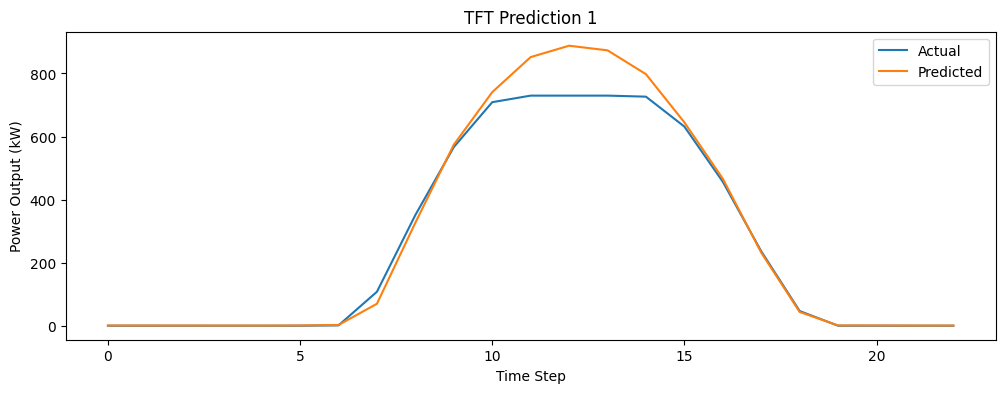

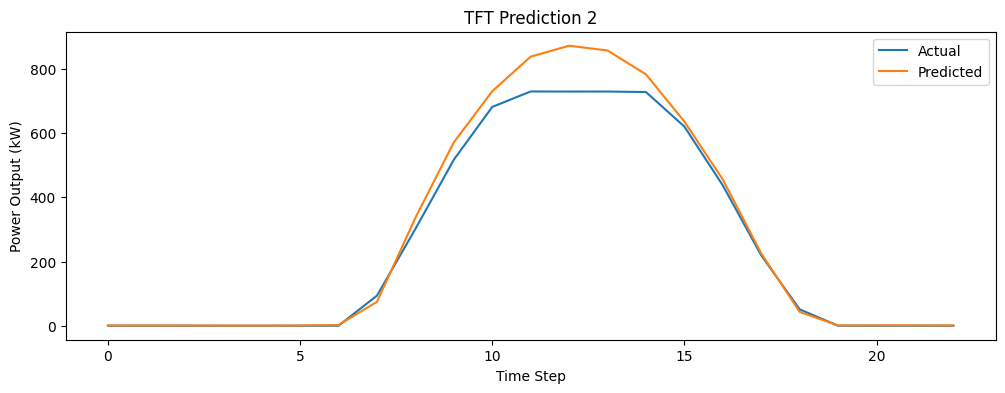

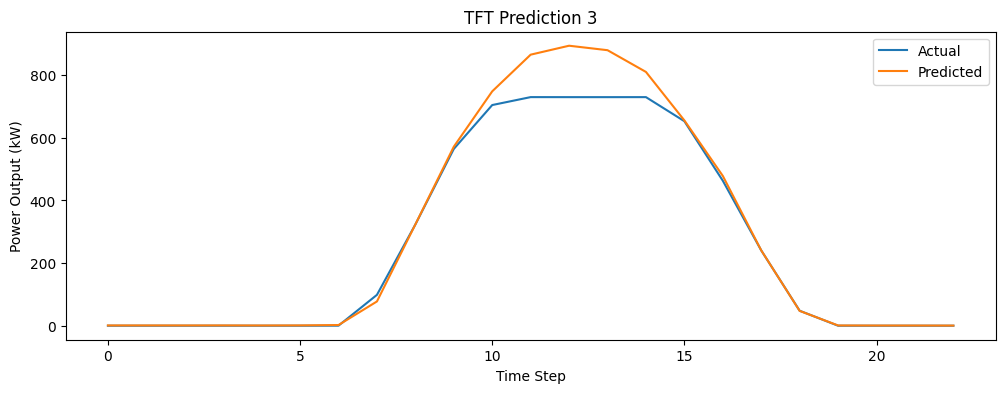

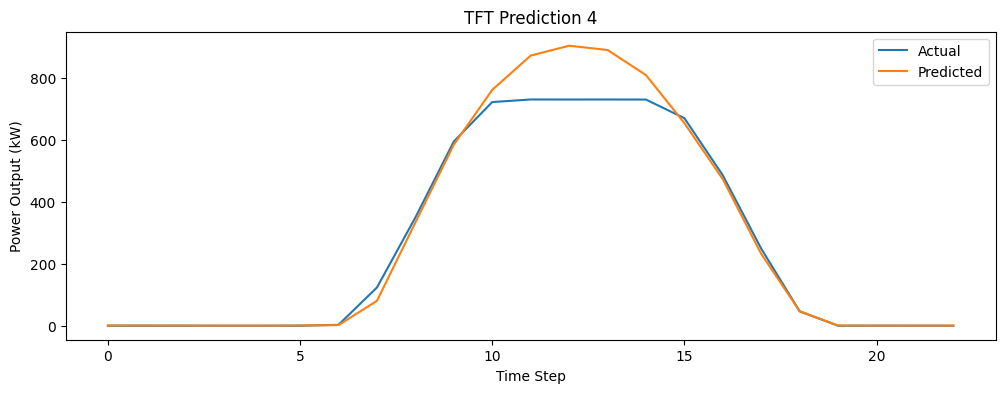

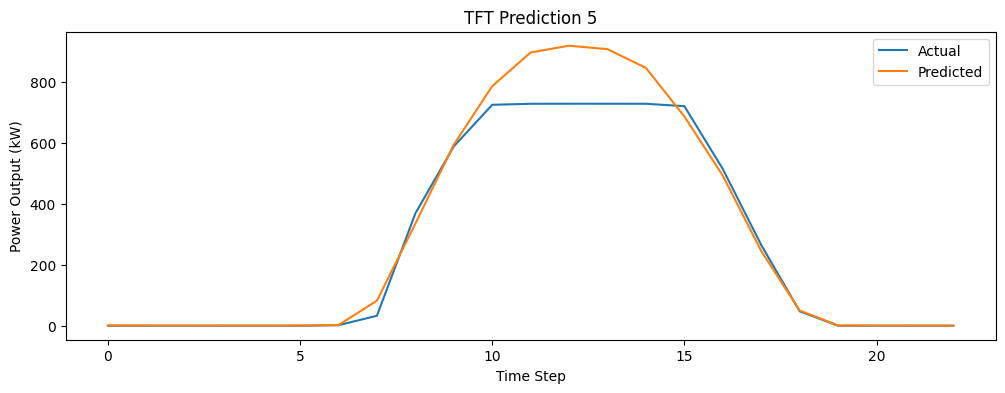

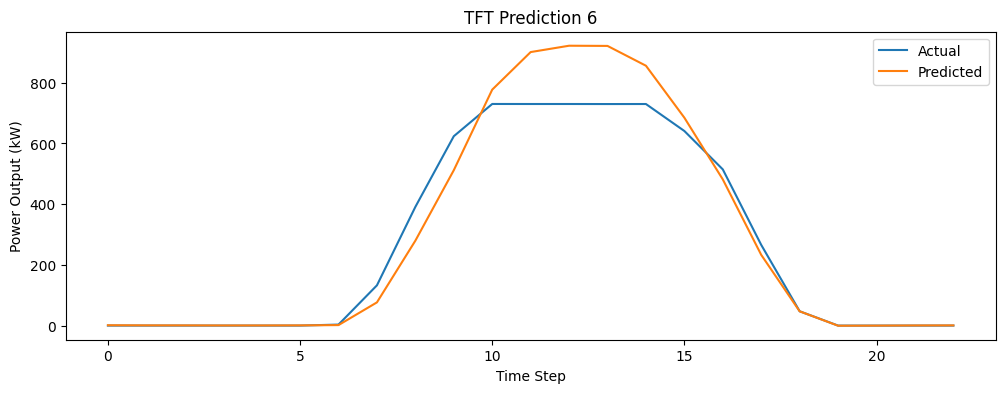

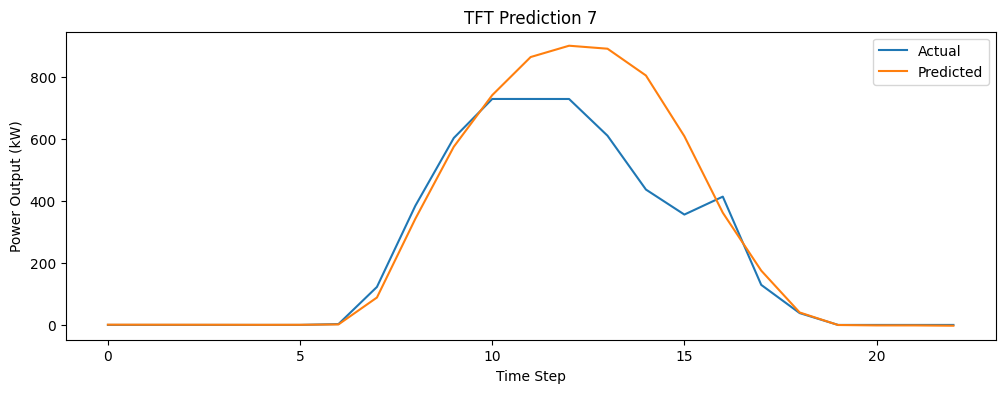

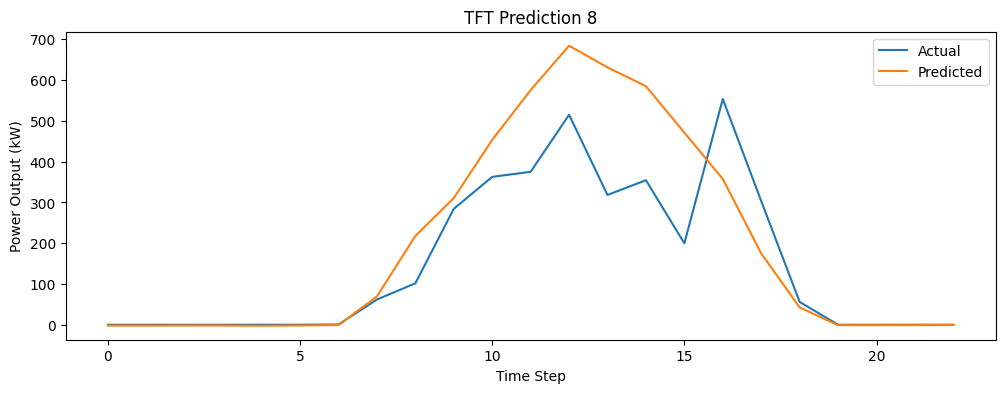

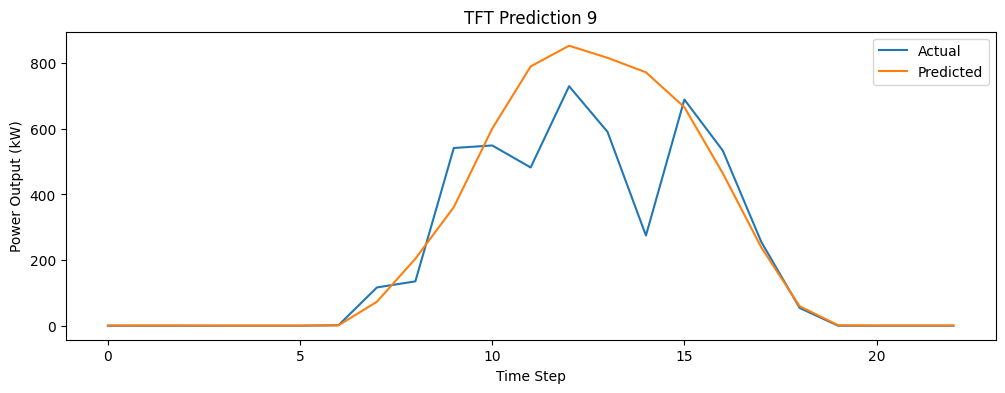

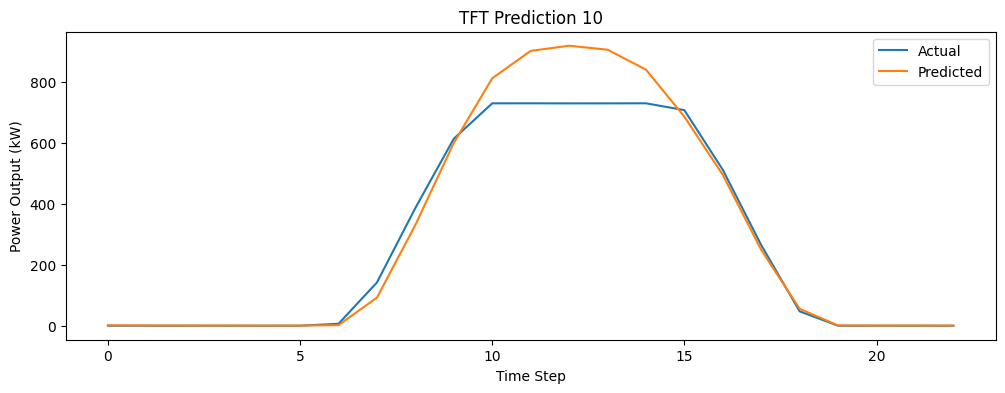

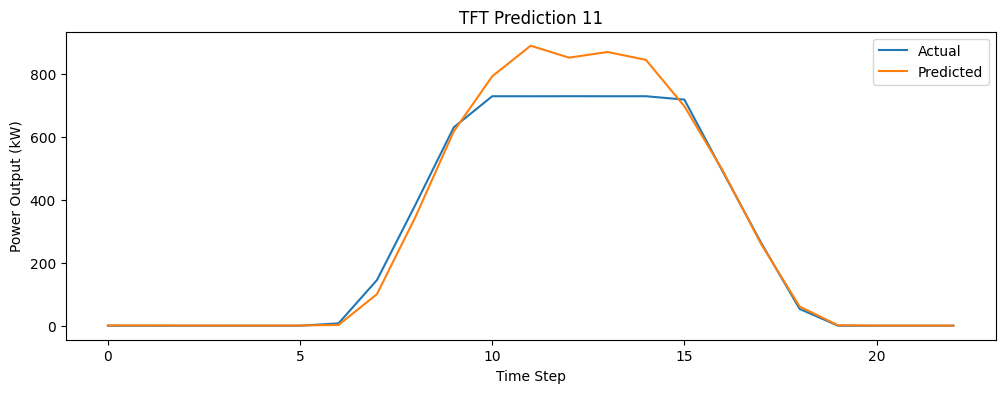

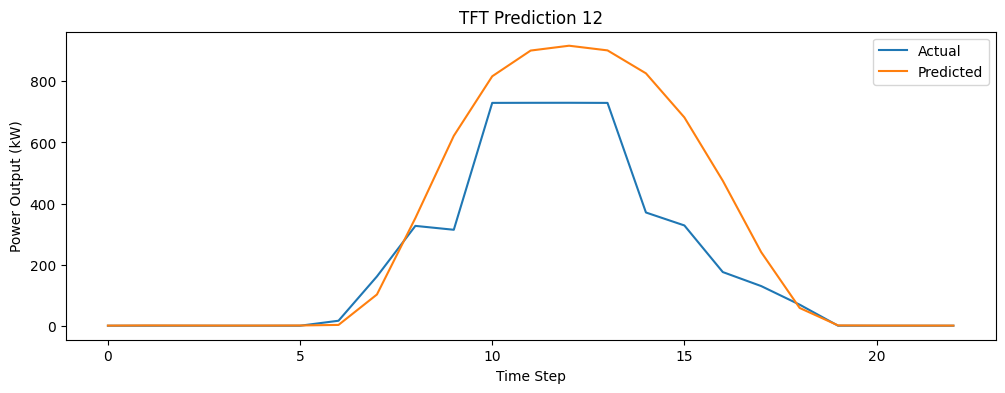

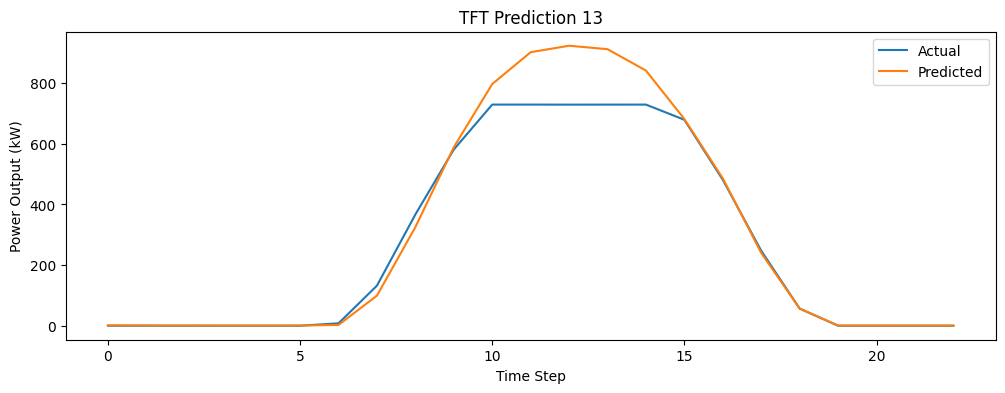

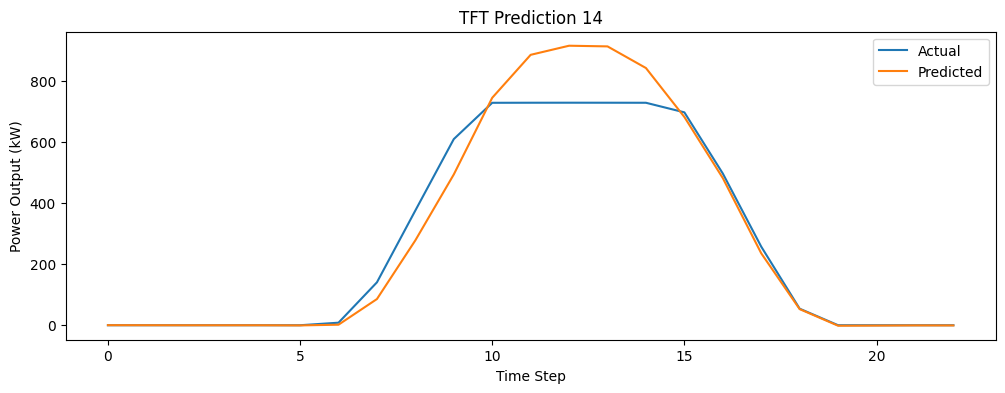

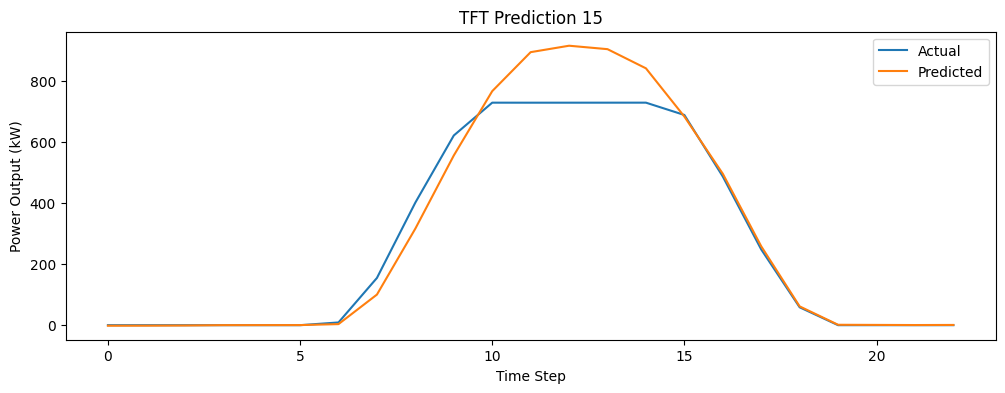

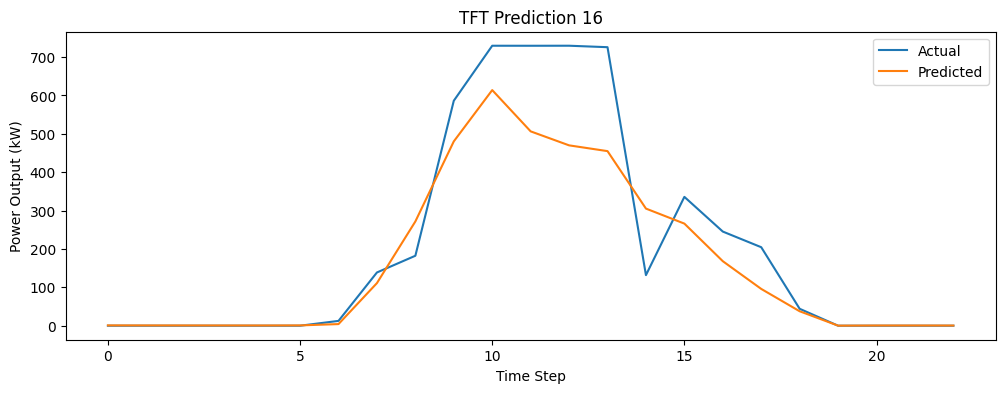

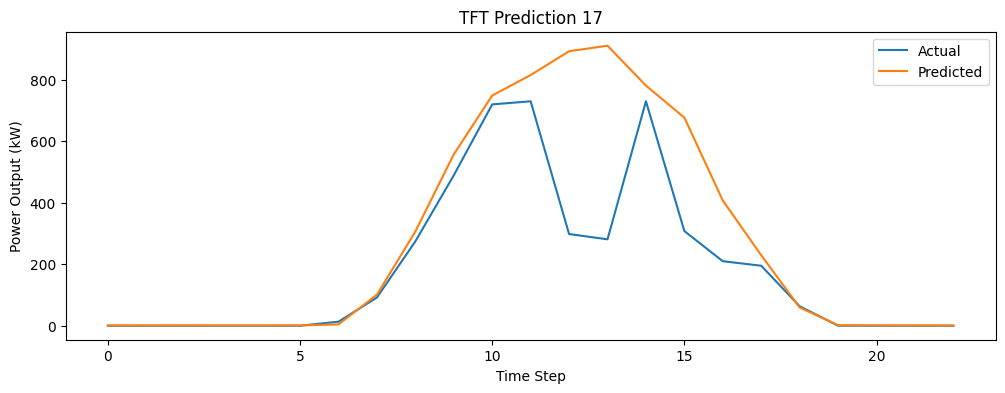

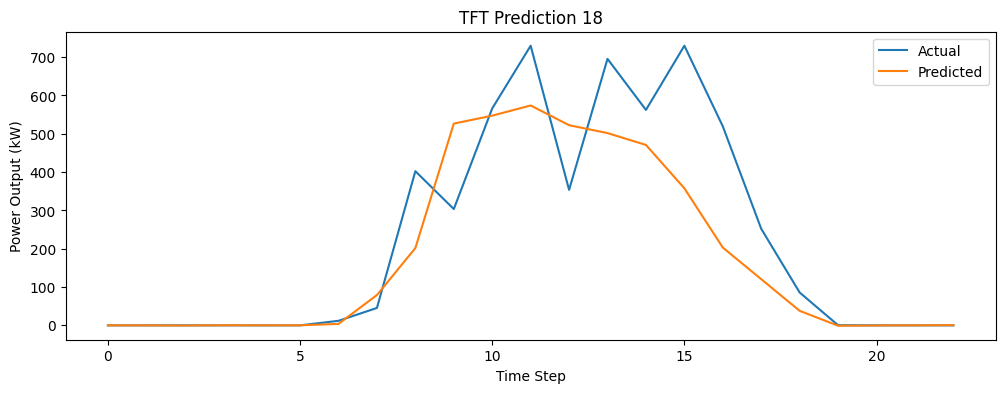

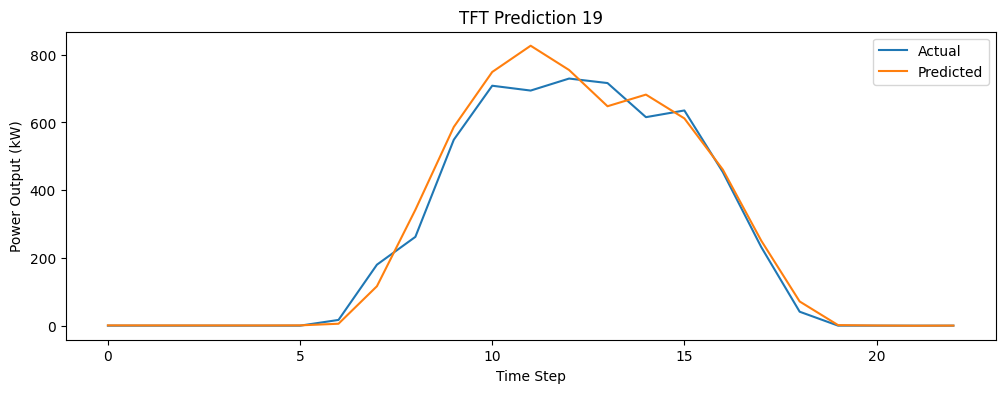

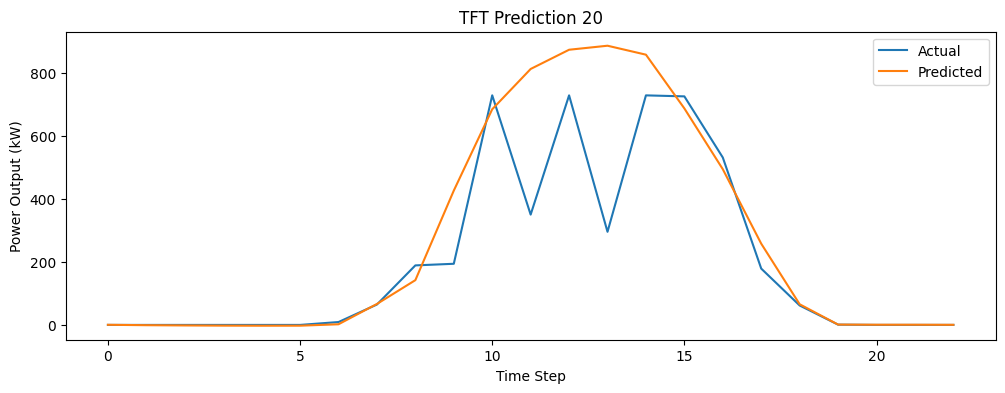

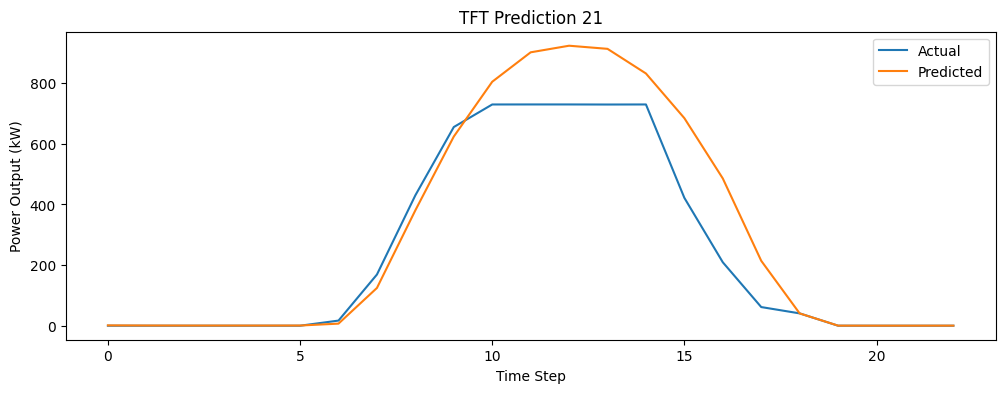

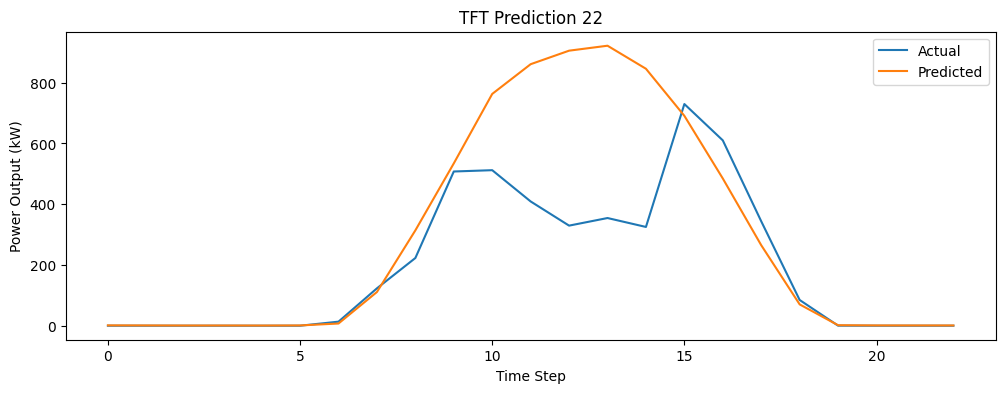

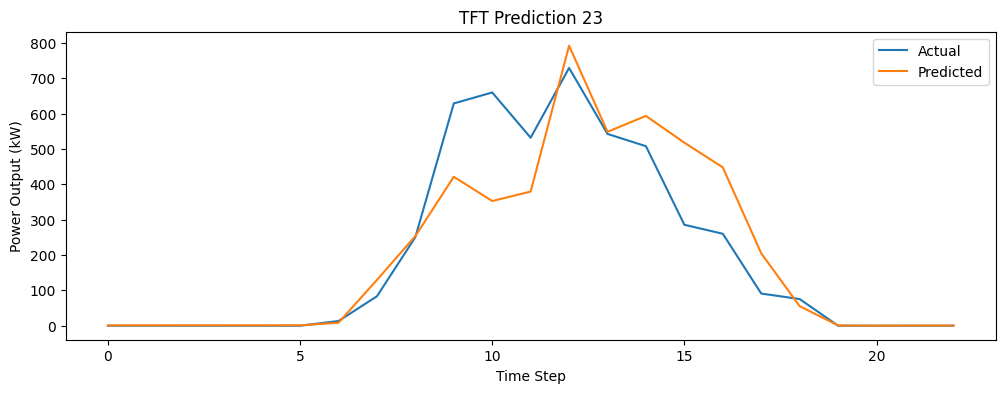

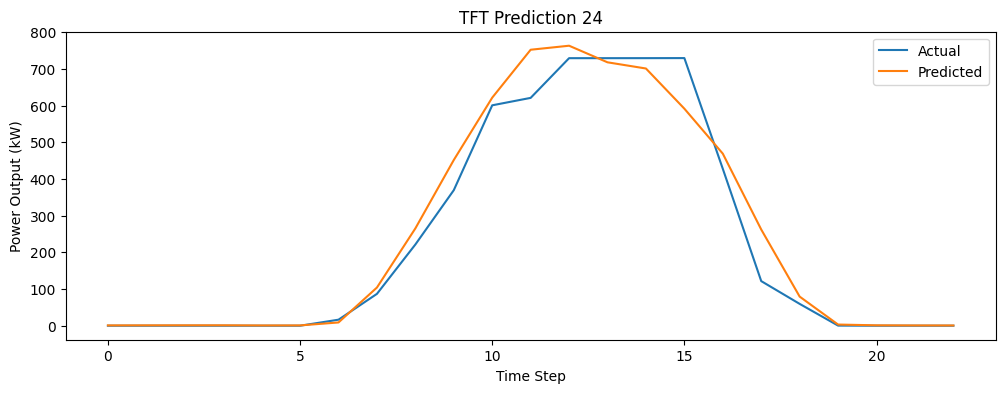

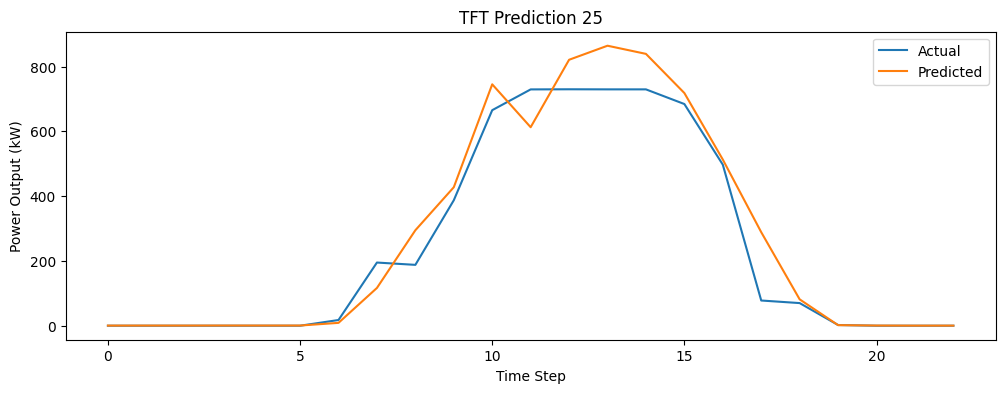

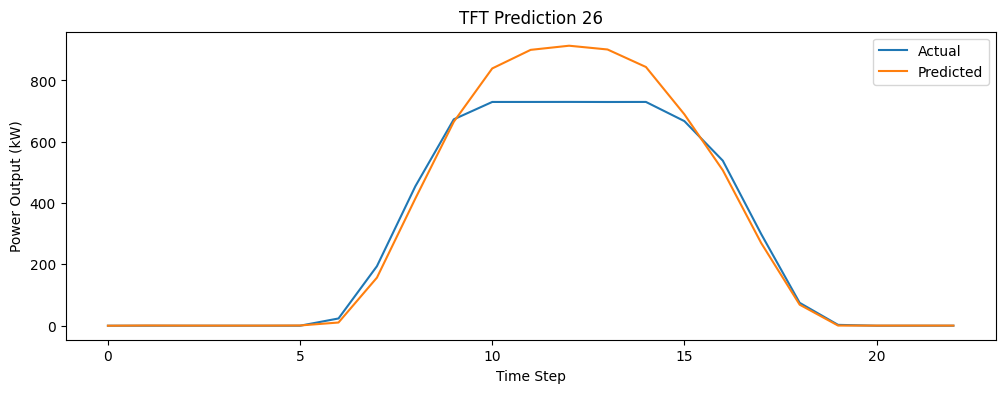

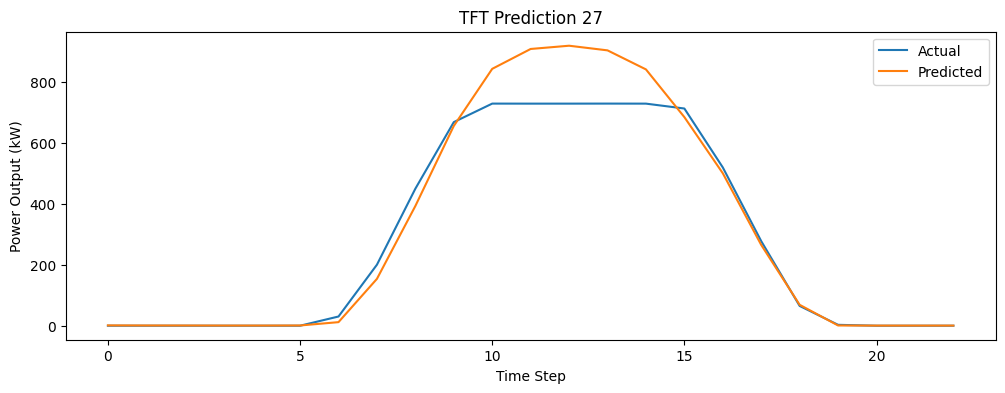

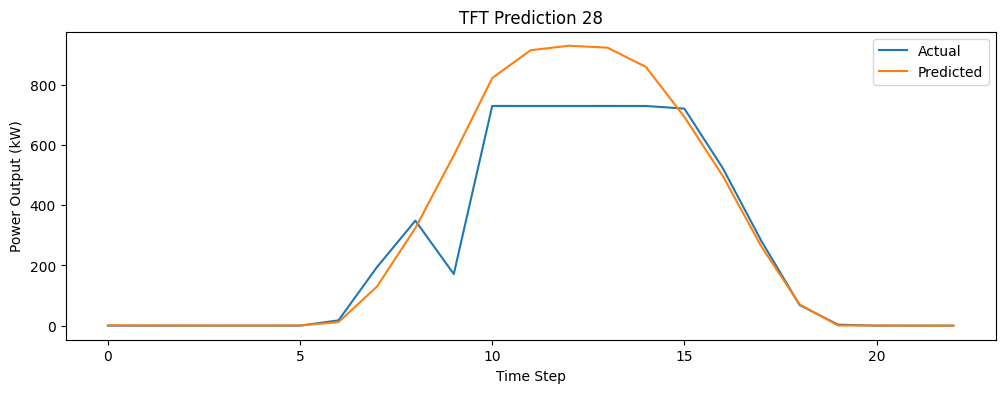

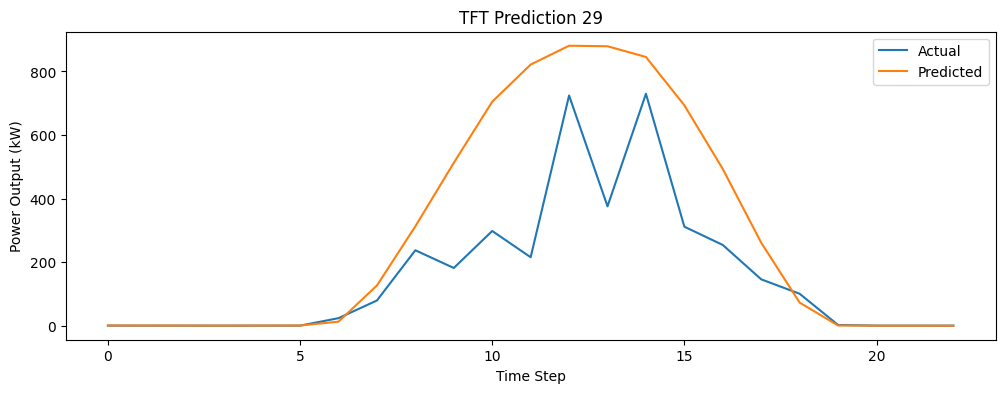

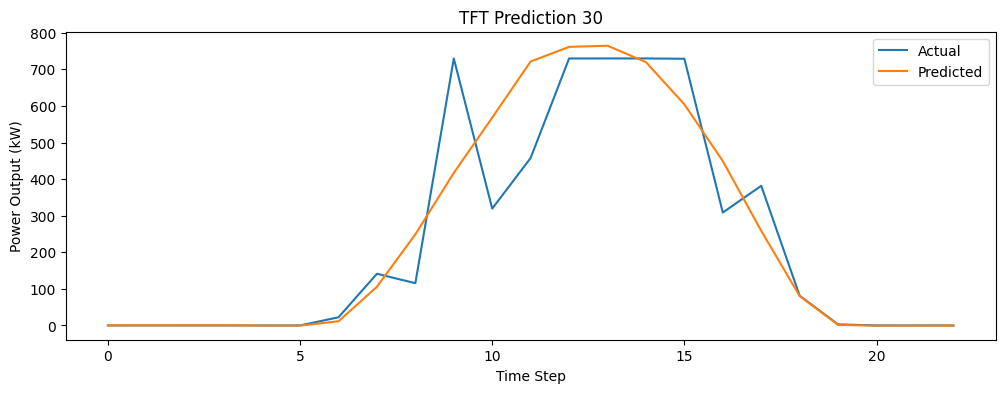

In [43]:
for i in range(30):
    plt.figure(figsize=(12, 4))
    plt.plot(y_true_inv[i], label='Actual')
    plt.plot(y_pred_inv[i], label='Predicted')
    plt.title(f"TFT Prediction {i+1}")
    plt.xlabel("Time Step")
    plt.ylabel("Power Output (kW)")  # Adjust based on units
    plt.legend()
    # plt.grid(True)
    plt.savefig(f"{base_dir}/model/TFT/prediction-scenarios/{weather_source}/{features}/test/2024-04/prediction_{i+1}.png")
    plt.show()
    plt.close()